In [29]:
from src.inference.generate import generative_prior, bayesian_inference, inference
from src.inference.conditional import half_callback_maker
import torch
from src.common.data_prep import dis_t
from src.datasets.dataset_helper import make_collate_fn
from src.datasets.shakespeare.shakespeare import ShakespeareDataset as Ds
from torch.nn.functional import one_hot
from torch.distributions import Categorical
from torch.nn import functional as F
import matplotlib.pyplot as plt
from src.inference.generate import TextBFNSolver
from accelerate import Accelerator
from tqdm.auto import tqdm
from src.nn.discrete_model import DiscreteModel as Model
from src.tokenizers.byte.byte import ByT5Tokenizer as Tk
from src.schedule.vanilla import VanillaScheduler as Scheduler
from src.checkpointing.checkpointing import load_checkpoint
from src.training.loss import loss
import matplotlib.pyplot as plt

In [2]:
accelerator = Accelerator(log_with="tensorboard", project_dir="./runs")
checkpoint_name = "shakespeare_byt5_packed_ebm_REINFORCE"
checkpoint_dir = "./checkpoints"
batch_size = 256
seq_len = 128
min_t = 1e-8
num_workers = 3
hidden_size = 768
layers = 6
heads = 12
use_chunkers = False
dropout = 0.1
tk = Tk()
vocab_size = tk.vocab_size()
scheduler = Scheduler(20.4054 / vocab_size)

In [3]:
model = Model(
    max_seq_len=seq_len,
    K=vocab_size,
    hidden_dim=hidden_size,
    num_heads=heads,
    layers=layers,
    dropout=dropout,
    use_chunkers=use_chunkers,
)

In [4]:
model, _, _, _ = load_checkpoint(model, None, None, accelerator, checkpoint_dir + f"/{checkpoint_name}")

In [5]:
model = model.eval()

In [6]:
ds = Ds(tk, seq_len, min_t=min_t, train=True)

collate_fn = make_collate_fn(scheduler, vocab_size)

/media/john/Tertiary/Projects/ML/BayesianFlowNet/.venv/lib/python3.12/site-packages/datasets/load.py:1461: FutureWarning: The repository for karpathy/tiny_shakespeare contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/karpathy/tiny_shakespeare
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


In [7]:
dl = torch.utils.data.DataLoader(
    ds,
    batch_size=1,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

In [8]:
dl = accelerator.prepare(dl)

In [9]:
batch = next(iter(dl))

In [10]:
model_input = batch["model_input"]
t = batch["t"]
ground_truth = batch["ground_truth"]
scheduler_output = batch["scheduler_output"]
mask = batch["mask"]
doc_ids = batch["document_id"]
steps = 100

In [11]:
mask.sum() / (mask.shape[0] * mask.shape[1])

tensor(0.2656, device='cuda:0')

In [12]:
mask.shape, model_input.shape

(torch.Size([1, 128]), torch.Size([1, 128, 256]))

In [13]:
solver = TextBFNSolver(model, vocab_size, 100, (20.4054 / vocab_size) ** 0.5)

In [55]:
beta_t = (solver.max_sqrt_beta * solver.eta) ** 2
std_t = (vocab_size * beta_t) ** 0.5
prior = torch.randn(ground_truth.shape[0], seq_len, vocab_size, device=ground_truth.device) * std_t
xt = prior

In [56]:
data_pred_last = None
ebm_energy = None
algorithm = "sde_bfnsolver2_multi_step"
error = []
min_error = float("inf")
best_xt = None
energies = []

In [57]:
def loss(model_logits, target, mask):
    batch, seq, K = model_logits.shape
    model_output = torch.softmax(model_logits, dim=-1)
    mse = (target - model_output) ** 2
    mse = mse * mask.unsqueeze(-1)
    seq_norm_loss = torch.sum(mse, dim=(-2, -1)) * 0.5 * vocab_size / seq
    return seq_norm_loss.mean()

In [61]:
loss(prior, ground_truth, mask)

tensor(33.8672, device='cuda:0')

In [58]:
for step in range(steps):
    if algorithm == "sde_euler":
        xt, _, ebm_energy = solver.sde_euler_update(
            xt, step, mask, model_input, doc_ids
        )
    elif algorithm == "sde_bfnsolver2_multi_step":
        xt, data_pred_last, ebm_energy = solver.sde_bfnsolver2_multi_step_update(
            xt, step, mask, model_input, doc_ids, data_pred_last
        )
    l = loss(xt, ground_truth, mask).item()
    error.append(l)
    energies.append(ebm_energy.item())
    if l < min_error:
        min_error = l
        best_xt = xt.clone()

In [60]:
error[0]

33.864749908447266

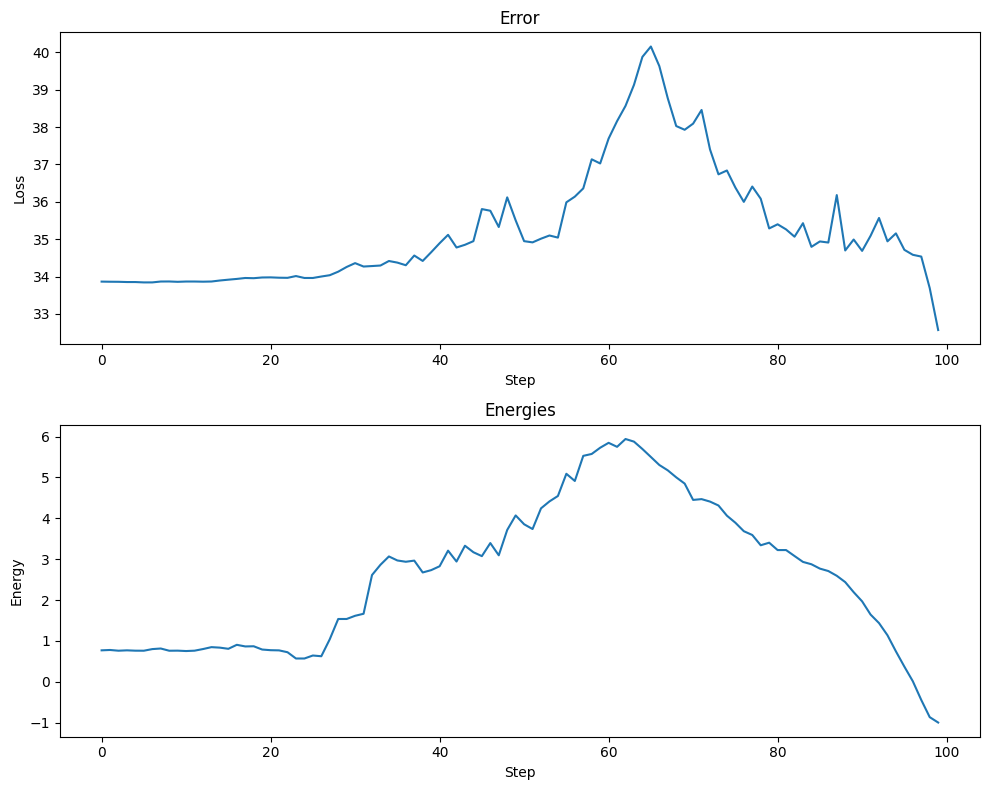

In [59]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

axs[0].plot(error)
axs[0].set_title('Error')
axs[0].set_xlabel('Step')
axs[0].set_ylabel('Loss')

axs[1].plot(energies)
axs[1].set_title('Energies')
axs[1].set_xlabel('Step')
axs[1].set_ylabel('Energy')

plt.tight_layout()
plt.show()

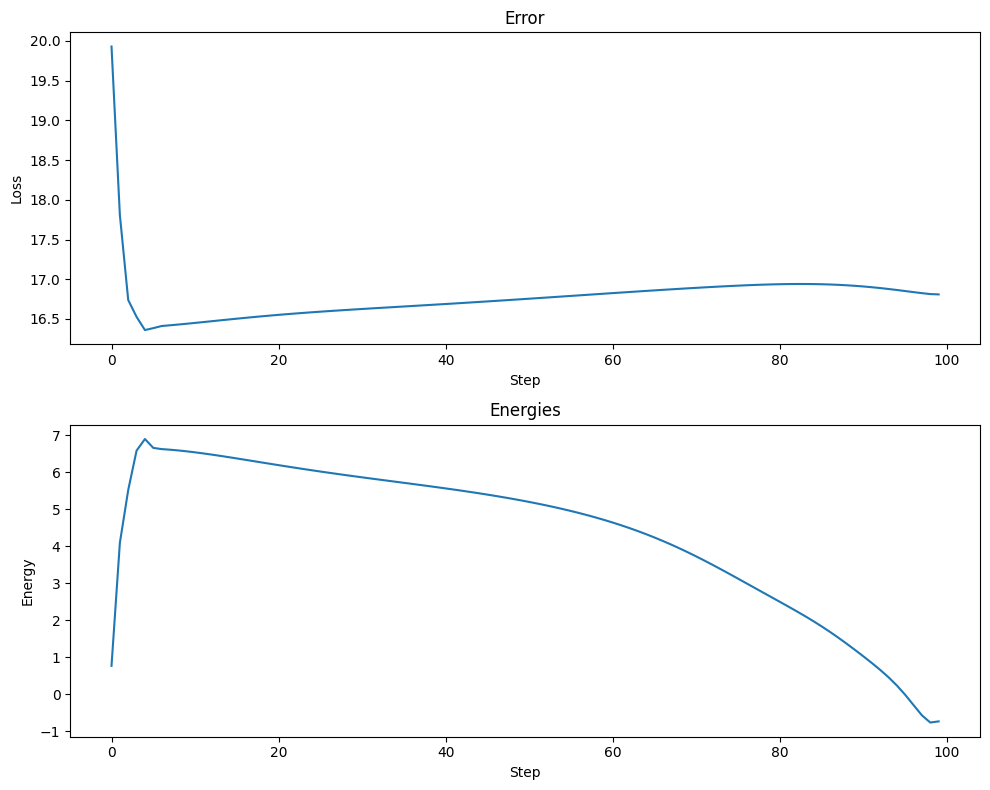

In [51]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

axs[0].plot(error)
axs[0].set_title('Error')
axs[0].set_xlabel('Step')
axs[0].set_ylabel('Loss')

axs[1].plot(energies)
axs[1].set_title('Energies')
axs[1].set_xlabel('Step')
axs[1].set_ylabel('Energy')

plt.tight_layout()
plt.show()

In [52]:
min_error

16.360597610473633

In [53]:
tk.decode(best_xt[0])

'n ways;\nWhether they ooe against the gates of Rome,\nOr rude revisit them in parts remote,\nTo fright them, ere destroy. But come '

In [54]:
tk.decode(xt[0])

'n ways;\nWhether they ooe against the gates of Rome,\nOr rude revisit them in parts remote,\nTo fright them, ere destroy. But come '